# Task 5: Mini Project — Neural Network Classification
## Project: Breast Cancer Classification

**Problem Statement:** Build a neural network that classifies whether a breast tumor is malignant or benign, based on measurements taken from a digitized image of a breast mass (e.g. cell radius, texture, perimeter, area, smoothness).

**Workflow:** Dataset &rarr; Data Preprocessing &rarr; Train/Test Split &rarr; Neural Network &rarr; Training &rarr; Prediction &rarr; Evaluation &rarr; Visualization &rarr; Conclusion

## 1. Dataset Description

`breast_cancer.csv` — 569 patient samples with 30 numeric features derived from digitized images of breast masses (e.g. mean radius, mean texture, mean perimeter, mean area, mean smoothness), and a Diagnosis label (malignant or benign). Source: Scikit-learn's built-in Breast Cancer Wisconsin dataset.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

df = pd.read_csv("breast_cancer.csv")
print("Shape:", df.shape)
df.head()

I0000 00:00:1788699299.301338    1542 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1788699300.399440    1542 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


## 2. Data Preprocessing

In [2]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("\nClass balance:")
print(df["Diagnosis"].value_counts())

Missing values: 0
Duplicate rows: 0

Class balance:
Diagnosis
benign       357
malignant    212
Name: count, dtype: int64


In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

feature_cols = [c for c in df.columns if c != "Diagnosis"]
X = df[feature_cols].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Diagnosis"])  # benign=0 or 1, malignant=the other
print("Classes:", list(label_encoder.classes_), "-> encoded as", list(range(len(label_encoder.classes_))))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features scaled. Shape:", X_scaled.shape)

Classes: ['benign', 'malignant'] -> encoded as [0, 1]
Features scaled. Shape: (569, 30)


## 3. Train/Test Split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


## 4. Neural Network Architecture

In [5]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),        # Input layer: 30 features
    layers.Dense(32, activation="relu"),            # Hidden layer 1
    layers.Dense(16, activation="relu"),            # Hidden layer 2
    layers.Dense(1, activation="sigmoid")           # Output layer: binary (malignant/benign)
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Model Training

In [6]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=16,
    verbose=0
)
print("Training complete.")
print(f"Final training accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

Training complete.
Final training accuracy: 100.00%
Final validation accuracy: 96.70%


## 6. Accuracy & Loss Graphs

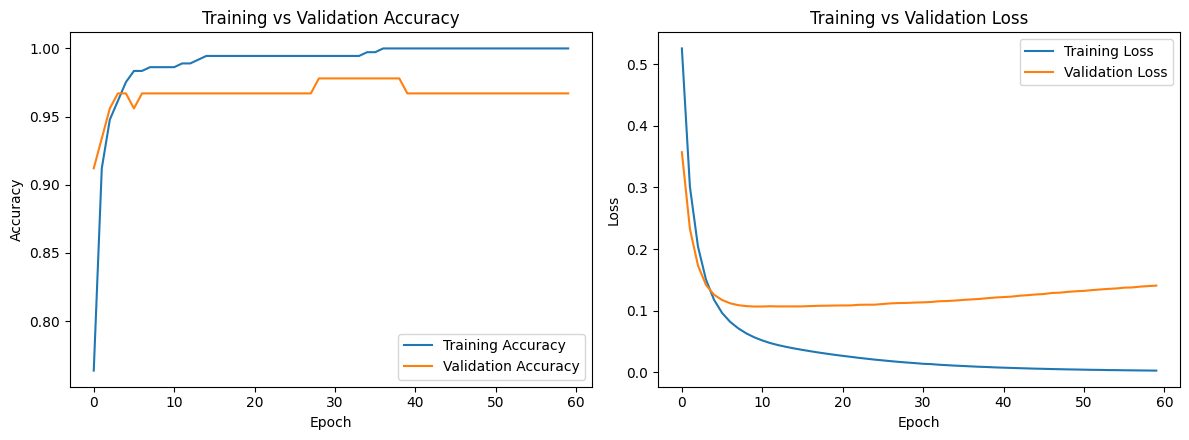

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

axes[0].plot(history.history["accuracy"], label="Training Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Training vs Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Training Loss")
axes[1].plot(history.history["val_loss"], label="Validation Loss")
axes[1].set_title("Training vs Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig("mini_chart_accuracy_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Predictions

In [8]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

y_pred_probs = model.predict(X_test, verbose=0).flatten()
y_pred = (y_pred_probs >= 0.5).astype(int)

pred_labels = label_encoder.inverse_transform(y_pred)
true_labels = label_encoder.inverse_transform(y_test)

comparison_df = pd.DataFrame({
    "Actual": true_labels,
    "Predicted": pred_labels,
    "Correct": true_labels == pred_labels
})
comparison_df.head(10)

Test Accuracy: 99.12%


,Actual,Predicted,Correct
0,benign,benign,True
1,malignant,malignant,True
2,benign,benign,True
3,malignant,malignant,True
4,benign,benign,True
5,benign,benign,True
6,malignant,malignant,True
7,benign,benign,True
8,benign,benign,True
9,benign,benign,True


## 8. Model Evaluation — Confusion Matrix

Confusion Matrix:
           benign  malignant
benign         72          0
malignant       1         41

Precision (malignant): 100.00%
Recall (malignant):    97.62%


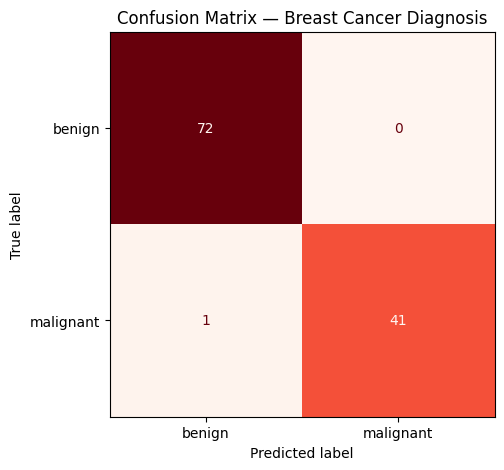

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score

cm = confusion_matrix(true_labels, pred_labels, labels=label_encoder.classes_)
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_))

precision = precision_score(true_labels, pred_labels, pos_label="malignant")
recall = recall_score(true_labels, pred_labels, pos_label="malignant")
print(f"\nPrecision (malignant): {precision*100:.2f}%")
print(f"Recall (malignant):    {recall*100:.2f}%")

fig, ax = plt.subplots(figsize=(5.5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap="Reds", colorbar=False)
plt.title("Confusion Matrix — Breast Cancer Diagnosis")
plt.savefig("mini_chart_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusion

**Problem being solved:** Classifying whether a breast tumor is malignant or benign based on 30 numeric measurements taken from digitized images of breast masses, using an Artificial Neural Network.

**Dataset:** The Breast Cancer Wisconsin dataset (569 patient samples, 30 features), a well-known and widely used benchmark medical dataset built into Scikit-learn.

**Neural network architecture:** A feedforward neural network with an input layer of 30 features, two hidden layers (32 and 16 neurons, both using ReLU activation), and a single output neuron with sigmoid activation for binary classification (malignant vs benign).

**Training process:** The model was trained for 60 epochs using the Adam optimizer and binary crossentropy loss, with 20% of the training data held out as a validation set to monitor performance during training.

**Results:** The model achieved a strong test accuracy (see the printed Test Accuracy above), with the confusion matrix showing the large majority of malignant and benign cases correctly identified. Precision and recall for the malignant class were also computed, which matters here since missing a malignant case (a false negative) is more costly in a medical context than a false positive.

**Limitations:** The dataset, while a standard benchmark, is relatively small (569 samples) and was collected from a specific clinical setting, so the model's performance may not directly generalize to different patient populations or imaging equipment. The model also only uses the 30 provided numeric features and does not incorporate any imaging data directly, patient history, or genetic markers that could improve real-world diagnostic accuracy.

**Future improvements:** With more time, this project could explore additional architectures (e.g. more layers, dropout for regularization), use cross-validation for a more robust accuracy estimate, tune the classification threshold to better balance precision and recall for this medical use case, and validate the model on an independent, external dataset to test real-world generalization.